# MAQT: Tune $\lambda_1$, $\lambda_2$ Sensitivity
## CICIoT2023 | FROZEN Features | 500/class DPP | Batch 64 | 5 Epochs | LR 0.01 (fixed)
## Target (y) = "label_multiclass" | Data Reupload = 2

## Setup

In [1]:
import json
import time
from collections import Counter
from itertools import product
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch
from pennylane import numpy as np
from sklearn.decomposition import PCA
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
from scripts.circuit import build_forward_circuit, create_quantum_device
from scripts.constants import BARREN_PLATEAU_VAR_THRESHOLD, DEFAULT_NOISE_RATE
from scripts.data import (
    capped_sample,
    greedy_dpp_sample,
    load_split,
    to_angles,
)
from scripts.inference import predict_labels
from scripts.logging import write_history_log
from scripts.memory import run_batched_safely, safe_empty_cache
from scripts.train import train_maqt
from scripts.utils import get_torch_device, to_np_y

In [3]:
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available?: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"CUDA device name: {torch.cuda.get_device_name(0)}")
    print(f"Current CUDA device index: {torch.cuda.current_device()}")

PyTorch version: 2.12.1+cu126
CUDA available?: True
CUDA device name: NVIDIA GeForce GTX 1060
Current CUDA device index: 0


## Paths

In [4]:
NOTEBOOK_NAME = "13.tune-lambdas-ciciot2023"

dataset = "CICIoT2023"
target_col = "label_multiclass"
data_path = f"data/FROZEN/{dataset}"
frozen_feat_path = "team-artifacts/teamC_week3_FROZEN_handoff.json"

SEED = 42

## Load Team C's FROZEN Features

In [5]:
handoff = json.loads(Path(frozen_feat_path).read_text())
FEATURE_COLS = list(handoff["frozen_subsets"][dataset]["features"])
print(f"Team C selector: {handoff['frozen_subsets'][dataset]['selector']}")
print(f"k={len(FEATURE_COLS)} features: {FEATURE_COLS}")

Team C selector: MI
k=10 features: ['duration', 'n_pkts_total', 'n_bytes_total', 'rate', 'pkt_size_min', 'pkt_size_max', 'pkt_size_mean', 'iat', 'protocol', 'conn_state']


## Load Team A's FROZEN Dataset

In [6]:
# load known-class splits
X_train_full, y_train_full, class_names, df_train = load_split(
    data_path, "train", target_col, csv=True, selected_cols=FEATURE_COLS, return_df=True
)

print(f"train : {X_train_full.shape, y_train_full.shape}\nclasses: {class_names}")
df_train.head(3)

train : ((151049, 10), (151049,))
classes: ['Backdoor_Malware', 'BenignTraffic', 'BrowserHijacking', 'CommandInjection', 'DDoS-ACK_Fragmentation', 'DDoS-HTTP_Flood', 'DDoS-ICMP_Flood', 'DDoS-ICMP_Fragmentation', 'DDoS-PSHACK_Flood', 'DDoS-RSTFINFlood', 'DDoS-SYN_Flood', 'DDoS-SlowLoris', 'DDoS-SynonymousIP_Flood', 'DDoS-TCP_Flood', 'DDoS-UDP_Flood', 'DDoS-UDP_Fragmentation', 'DNS_Spoofing', 'DictionaryBruteForce', 'DoS-HTTP_Flood', 'DoS-SYN_Flood', 'DoS-TCP_Flood', 'DoS-UDP_Flood', 'MITM-ArpSpoofing', 'Recon-HostDiscovery', 'Recon-OSScan', 'Recon-PingSweep', 'Recon-PortScan', 'SqlInjection', 'Uploading_Attack', 'VulnerabilityScan', 'XSS']


,duration,n_pkts_total,n_bytes_total,rate,pkt_size_min,pkt_size_max,pkt_size_mean,iat,protocol,conn_state,label_multiclass
0,0.114311,0.627152,0.005499,-0.306870,0.000000,0.050420,0.000000,0.855064,0.000000,-1.368171,DDoS-RSTFINFlood
1,11.888079,59.170326,2.426720,0.744359,2.613771,22.605136,11.713125,-314.863555,-1.322219,-1.217438,BenignTraffic
2,0.000000,-0.250922,-3.264916,0.257804,-3.259715,-2.850162,-3.252384,0.020018,-1.000000,0.000000,DDoS-ICMP_Flood


## Data Subset

- Class imbalance handled inside `train_maqt` via `use_weighted_sampler=True`.

In [7]:
SUBSET = True  # set to False for the full dataset
PER_CLASS_CAP = 500
USE_DPP = True  # set to False to use capped_sample

In [8]:
if SUBSET:
    if USE_DPP:
        print(f"Running representative DPP coreset sampling (cap={PER_CLASS_CAP})...")
        X_train, y_train = greedy_dpp_sample(
            X_train_full, y_train_full, per_class_cap=PER_CLASS_CAP, seed=SEED
        )
    else:
        print(f"Running capped_sample (cap={PER_CLASS_CAP})...")
        X_train, y_train = capped_sample(
            X_train_full, y_train_full, per_class_cap=PER_CLASS_CAP, seed=SEED
        )
    print(f"Coreset selected: {X_train.shape[0]} samples.")
else:
    X_train, y_train = X_train_full, y_train_full
    print(f"using full train (no subset): {X_train.shape[0]} samples")

print(
    f"train raw: {X_train.shape, y_train.shape} | SUBSET={SUBSET} | cap={PER_CLASS_CAP if SUBSET else 'all'}"
)

Running representative DPP coreset sampling (cap=500)...
Coreset selected: 11852 samples.
train raw: ((11852, 10), (11852,)) | SUBSET=True | cap=500


In [9]:
# class counts on coreset (pre-holdout)
y_np = to_np_y(y_train).astype(int)
counts = Counter(y_np.tolist())
print("train class counts:", {class_names[c]: counts[c] for c in sorted(counts)})

train class counts: {'Backdoor_Malware': 75, 'BenignTraffic': 500, 'BrowserHijacking': 125, 'CommandInjection': 106, 'DDoS-ACK_Fragmentation': 500, 'DDoS-HTTP_Flood': 500, 'DDoS-ICMP_Flood': 500, 'DDoS-ICMP_Fragmentation': 500, 'DDoS-PSHACK_Flood': 500, 'DDoS-RSTFINFlood': 500, 'DDoS-SYN_Flood': 500, 'DDoS-SlowLoris': 493, 'DDoS-SynonymousIP_Flood': 500, 'DDoS-TCP_Flood': 500, 'DDoS-UDP_Flood': 500, 'DDoS-UDP_Fragmentation': 500, 'DNS_Spoofing': 500, 'DictionaryBruteForce': 230, 'DoS-HTTP_Flood': 500, 'DoS-SYN_Flood': 500, 'DoS-TCP_Flood': 500, 'DoS-UDP_Flood': 500, 'MITM-ArpSpoofing': 500, 'Recon-HostDiscovery': 463, 'Recon-OSScan': 331, 'Recon-PingSweep': 37, 'Recon-PortScan': 277, 'SqlInjection': 116, 'Uploading_Attack': 27, 'VulnerabilityScan': 500, 'XSS': 72}


## Scale / PCA / Angle Encoding

In [10]:
# fit scaler on full train (raw); transform elsewhere via to_angles()
scaler = StandardScaler()
X_train_full_scaled = scaler.fit_transform(X_train_full)
print(f"scaled full train: {X_train_full_scaled.shape}")

scaled full train: (151049, 10)


In [11]:
USE_PCA = True
TARGET_VARIANCE = 0.95

In [12]:
if USE_PCA:
    pca_full = PCA(random_state=SEED).fit(X_train_full_scaled)
    ratios = pca_full.explained_variance_ratio_
    cum = np.cumsum(ratios)
    n_feat = len(ratios)
    print(f"features (raw dim): {n_feat}")
    print("explained_variance_ratio_:", np.round(ratios, 4))
    print("cumulative:               ", np.round(cum, 4))

    k95 = int(np.searchsorted(cum, TARGET_VARIANCE) + 1)
    k95 = min(k95, len(cum))
    print(f"components needed for >={TARGET_VARIANCE * 100}% variance: {k95}")

    pca = PCA(n_components=k95, random_state=SEED)
    X_train_full_feat = pca.fit_transform(X_train_full_scaled)
else:
    pca = None
    k95 = X_train_full_scaled.shape[1]
    X_train_full_feat = X_train_full_scaled

x_min = X_train_full_feat.min(axis=0)
x_max = X_train_full_feat.max(axis=0)
print(f"angle bounds shape: {x_min.shape} | USE_PCA={USE_PCA} | k95={k95}")

features (raw dim): 10
explained_variance_ratio_: [4.321e-01 1.754e-01 1.195e-01 1.063e-01 6.910e-02 5.720e-02 2.430e-02
 1.340e-02 2.500e-03 3.000e-04]
cumulative:                [0.4321 0.6075 0.727  0.8333 0.9024 0.9596 0.9838 0.9973 0.9997 1.    ]
components needed for >=95.0% variance: 6
angle bounds shape: (6,) | USE_PCA=True | k95=6


In [13]:
# raw -> scale -> optional pca -> [0, pi] using bounds from full train
X_train_angles_all = to_angles(
    X_train, scaler, x_min, x_max, pca=pca if USE_PCA else None, angle_max=np.pi
)

# seeded stratified holdout from train for val (cal/test untouched)
VAL_FRAC = 0.1
_y_all = y_train
idx = np.arange(len(X_train_angles_all))
idx_fit, idx_val = train_test_split(
    idx,
    test_size=VAL_FRAC,
    stratify=_y_all,
    random_state=SEED,
)
X_train_angles, y_train = X_train_angles_all[idx_fit], _y_all[idx_fit]
X_val_angles, y_val = X_train_angles_all[idx_val], _y_all[idx_val]
print(
    f"angles fit: {X_train_angles.shape} | val: {X_val_angles.shape} | "
    f"VAL_FRAC={VAL_FRAC} | USE_PCA={USE_PCA} | SUBSET={SUBSET}"
)

angles fit: (10666, 6) | val: (1186, 6) | VAL_FRAC=0.1 | USE_PCA=True | SUBSET=True


## Quantum Circuit

In [14]:
num_classes = len(class_names)
num_qubits = int(k95)  # pca comps if USE_PCA; else scaled feature dim
num_layers = 2
noise_rate = DEFAULT_NOISE_RATE
device = get_torch_device()

print(f"classes: {class_names}")
print(f"num_classes={num_classes} | num_qubits={num_qubits} | device={device}")

classes: ['Backdoor_Malware', 'BenignTraffic', 'BrowserHijacking', 'CommandInjection', 'DDoS-ACK_Fragmentation', 'DDoS-HTTP_Flood', 'DDoS-ICMP_Flood', 'DDoS-ICMP_Fragmentation', 'DDoS-PSHACK_Flood', 'DDoS-RSTFINFlood', 'DDoS-SYN_Flood', 'DDoS-SlowLoris', 'DDoS-SynonymousIP_Flood', 'DDoS-TCP_Flood', 'DDoS-UDP_Flood', 'DDoS-UDP_Fragmentation', 'DNS_Spoofing', 'DictionaryBruteForce', 'DoS-HTTP_Flood', 'DoS-SYN_Flood', 'DoS-TCP_Flood', 'DoS-UDP_Flood', 'MITM-ArpSpoofing', 'Recon-HostDiscovery', 'Recon-OSScan', 'Recon-PingSweep', 'Recon-PortScan', 'SqlInjection', 'Uploading_Attack', 'VulnerabilityScan', 'XSS']
num_classes=31 | num_qubits=6 | device=cuda


In [15]:
dev = create_quantum_device(num_qubits)
forward_circuit = build_forward_circuit(
    dev, num_qubits, num_layers, noise_rate=noise_rate
)

## Training

Uses `scripts.train.train_maqt` (same path as real MAQT notebooks):
- EMA prototypes + new $L_{inter}$ ($\rho$ vs other-class EMA)
- weighted sampler, curriculum on $\lambda$, cosine LR schedule
- OOM-safe via `run_batched_safely`

$$
L = L_{CE} + \lambda_1 L_{intra} + \lambda_2 L_{inter}
$$

In [16]:
# # smoke test
# lambda1_grid = [0.0, 0.1]
# lambda2_grid = [0.0, 0.1]

# real test
lambda1_grid = [0.0, 0.33, 0.66, 1.0]
lambda2_grid = [0.0, 0.33, 0.66, 1.0]

lambda_grid = list(product(lambda1_grid, lambda2_grid))
print(f"grid size: {len(lambda_grid)} runs")
for a, b in lambda_grid:
    print(f"  λ1={a}, λ2={b}")

grid size: 16 runs
  λ1=0.0, λ2=0.0
  λ1=0.0, λ2=0.33
  λ1=0.0, λ2=0.66
  λ1=0.0, λ2=1.0
  λ1=0.33, λ2=0.0
  λ1=0.33, λ2=0.33
  λ1=0.33, λ2=0.66
  λ1=0.33, λ2=1.0
  λ1=0.66, λ2=0.0
  λ1=0.66, λ2=0.33
  λ1=0.66, λ2=0.66
  λ1=0.66, λ2=1.0
  λ1=1.0, λ2=0.0
  λ1=1.0, λ2=0.33
  λ1=1.0, λ2=0.66
  λ1=1.0, λ2=1.0


In [17]:
seed = SEED
epochs = 5
batch_size = 64
lr = 0.01
use_lr_schedule = False  # set True for cosine LR schedule; fixed budget so lambda pairs are comparable
early_stopping = (
    False  # set True for early stopping; fixed budget so lambda pairs are comparable
)
barren_plateau_var = BARREN_PLATEAU_VAR_THRESHOLD

X_train = X_train_angles
X_val = X_val_angles

In [18]:
def train_one_lambda(lambda1, lambda2):
    """
    One MAQT run via train_maqt (EMA, curriculum lambdas, cosine LR, weighted sampler).
    """
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    t0 = time.perf_counter()
    safe_empty_cache()

    result = run_batched_safely(
        train_maqt,
        X_train,
        y_train,
        n_classes=num_classes,
        n_qubits=num_qubits,
        n_layers=num_layers,
        forward_circuit=forward_circuit,
        device=device,
        epochs=epochs,
        lr=lr,
        use_lr_schedule=use_lr_schedule,
        batch_size=batch_size,
        min_batch=2,
        label=f"train_maqt_l1={lambda1}_l2={lambda2}",
        lambda1_max=lambda1,
        lambda2_max=lambda2,
        use_weighted_sampler=True,
        seed=seed,
        early_stopping=early_stopping,
        X_val=X_val,
        y_val=y_val,
        checkpoint_dir=None,
        save_every_epoch=False,
        heartbeat_every_steps=None,
        notebook_name=f"{NOTEBOOK_NAME}_l1-{lambda1}_l2-{lambda2}",
        log_dir=None,
        verbose=True,
    )

    if result is None:
        raise RuntimeError(
            f"train_maqt failed even at min_batch (λ1={lambda1}, λ2={lambda2})"
        )

    theta, head, prototypes, ema_protos, history = result
    safe_empty_cache()

    y_true, y_pred = predict_labels(X_val, y_val, theta, head, forward_circuit, device)
    val_f1 = float(f1_score(y_true, y_pred, average="macro", zero_division=0))

    gvars = history.get("grad_var") or []
    finite_gvars = [float(g) for g in gvars if g is not None]
    grad_var_min = float(min(finite_gvars)) if finite_gvars else None
    # only flag barren when we actually recorded gradient variance
    barren_any = (
        bool(any(g < barren_plateau_var for g in finite_gvars))
        if finite_gvars
        else False
    )

    l_intra_hist = history.get("L_intra") or []
    l_inter_hist = history.get("L_inter") or []
    val_loss_hist = history.get("val_loss") or []

    summary = {
        "lambda1": float(lambda1),
        "lambda2": float(lambda2),
        "epochs": int(history.get("epochs_ran", epochs)),
        "train_sec": float(time.perf_counter() - t0),
        "val_macro_f1_last": val_f1,
        "val_macro_f1_best": val_f1,  # end-of-run head (train_maqt has no F1 early-stop)
        "val_loss_last": float(val_loss_hist[-1]) if val_loss_hist else None,
        "val_loss_best": float(min(val_loss_hist)) if val_loss_hist else None,
        "l_intra_last": float(l_intra_hist[-1]) if l_intra_hist else None,
        "l_inter_last": float(l_inter_hist[-1]) if l_inter_hist else None,
        "grad_var_last": float(finite_gvars[-1]) if finite_gvars else None,
        "grad_var_min": grad_var_min,
        "barren_plateau_any": barren_any,
        "barren_plateau_ok": not barren_any,
    }

    print(
        f"[λ1={lambda1}, λ2={lambda2}] done | "
        f"val_f1={val_f1:.4f} | "
        f"l_intra={summary['l_intra_last']} | "
        f"l_inter={summary['l_inter_last']} | "
        f"barren={barren_any}"
    )
    return history, summary

In [19]:
sensitivity_rows = []
histories = {}

for lambda1, lambda2 in lambda_grid:
    print("=" * 72)
    print(f"training λ1={lambda1}, λ2={lambda2}")
    hist, summary = train_one_lambda(lambda1, lambda2)
    histories[(lambda1, lambda2)] = hist
    sensitivity_rows.append(summary)

sensitivity_df = pd.DataFrame(sensitivity_rows).sort_values(
    ["val_macro_f1_best", "l_intra_last"], ascending=[False, True]
)
sensitivity_df

training λ1=0.0, λ2=0.0
epoch  1/5 | time 1350.2s | loss 3.0268 | L_CE 3.0268 | L_intra 0.2346 | L_inter -0.8160 | grad_var 3.40e-04 | intra_fid 0.765 | inter_TD 0.694 | val_loss 2.7159 | peak_mem=267MB
epoch  2/5 | time 1357.5s | loss 2.6564 | L_CE 2.6564 | L_intra 0.2288 | L_inter -0.8191 | grad_var 7.55e-04 | intra_fid 0.771 | inter_TD 0.696 | val_loss 2.4853 | peak_mem=267MB
epoch  3/5 | time 1339.1s | loss 2.4676 | L_CE 2.4676 | L_intra 0.2276 | L_inter -0.8130 | grad_var 9.02e-04 | intra_fid 0.772 | inter_TD 0.686 | val_loss 2.3088 | peak_mem=267MB
epoch  4/5 | time 1336.5s | loss 2.3669 | L_CE 2.3669 | L_intra 0.2270 | L_inter -0.8087 | grad_var 1.27e-03 | intra_fid 0.773 | inter_TD 0.690 | val_loss 2.1969 | peak_mem=267MB
epoch  5/5 | time 1335.1s | loss 2.2669 | L_CE 2.2669 | L_intra 0.2282 | L_inter -0.8064 | grad_var 1.44e-03 | intra_fid 0.772 | inter_TD 0.688 | val_loss 2.0915 | peak_mem=267MB
[λ1=0.0, λ2=0.0] done | val_f1=0.2460 | l_intra=0.22816257271249066 | l_inter=-0.

,lambda1,lambda2,epochs,train_sec,val_macro_f1_last,val_macro_f1_best,val_loss_last,val_loss_best,l_intra_last,l_inter_last,grad_var_last,grad_var_min,barren_plateau_any,barren_plateau_ok
3,0.00,1.00,5,7084.313347,0.262039,0.262039,1.261423,1.261423,0.253353,-0.813920,0.001598,0.00034,False,True
2,0.00,0.66,5,7096.432644,0.256266,0.256266,1.528728,1.528728,0.256107,-0.815005,0.001567,0.00034,False,True
1,0.00,0.33,5,7242.668139,0.255435,0.255435,1.785073,1.785073,0.256401,-0.815357,0.001564,0.00034,False,True
6,0.33,0.66,5,7337.711224,0.250638,0.250638,1.622062,1.622062,0.232309,-0.807416,0.001471,0.00034,False,True
0,0.00,0.00,5,7161.372822,0.245963,0.245963,2.091497,2.091497,0.228163,-0.806378,0.001440,0.00034,False,True
5,0.33,0.33,5,7205.466796,0.245080,0.245080,1.892514,1.892514,0.228291,-0.807133,0.001461,0.00034,False,True
11,0.66,1.00,5,6258.327764,0.244230,0.244230,1.421387,1.421387,0.228734,-0.807556,0.001490,0.00034,False,True
4,0.33,0.00,5,7089.311876,0.244035,0.244035,2.158674,2.158674,0.227438,-0.806776,0.001457,0.00034,False,True
10,0.66,0.66,5,6333.064915,0.243657,0.243657,1.695389,1.695389,0.228193,-0.807327,0.001485,0.00034,False,True
9,0.66,0.33,5,6256.285496,0.243527,0.243527,1.960888,1.960888,0.227564,-0.807069,0.001482,0.00034,False,True


In [20]:
cols = [
    "lambda1",
    "lambda2",
    "val_macro_f1_best",
    "val_loss_best",
    "l_intra_last",
    "l_inter_last",
    "grad_var_min",
    "barren_plateau_any",
    "barren_plateau_ok",
    "train_sec",
]
print(sensitivity_df[cols].to_string(index=False))
print(
    f"barren collapses: {int(sensitivity_df['barren_plateau_any'].sum())}/{len(sensitivity_df)}"
)

 lambda1  lambda2  val_macro_f1_best  val_loss_best  l_intra_last  l_inter_last  grad_var_min  barren_plateau_any  barren_plateau_ok   train_sec
    0.00     1.00           0.262039       1.261423      0.253353     -0.813920       0.00034               False               True 7084.313347
    0.00     0.66           0.256266       1.528728      0.256107     -0.815005       0.00034               False               True 7096.432644
    0.00     0.33           0.255435       1.785073      0.256401     -0.815357       0.00034               False               True 7242.668139
    0.33     0.66           0.250638       1.622062      0.232309     -0.807416       0.00034               False               True 7337.711224
    0.00     0.00           0.245963       2.091497      0.228163     -0.806378       0.00034               False               True 7161.372822
    0.33     0.33           0.245080       1.892514      0.228291     -0.807133       0.00034               False               Tr

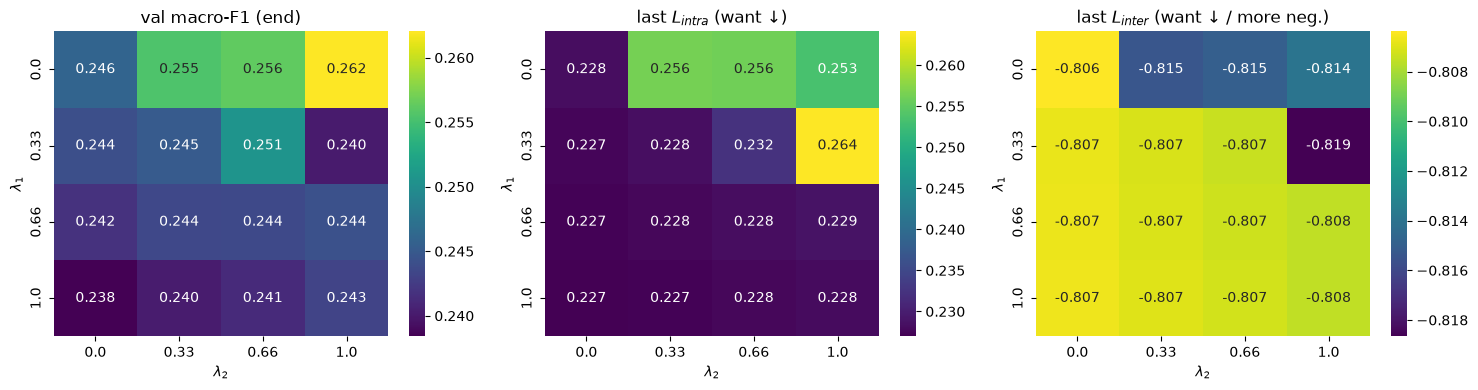

In [21]:
# plots (heatmap)
pivot_f1 = sensitivity_df.pivot(
    index="lambda1", columns="lambda2", values="val_macro_f1_best"
)
pivot_intra = sensitivity_df.pivot(
    index="lambda1", columns="lambda2", values="l_intra_last"
)
pivot_inter = sensitivity_df.pivot(
    index="lambda1", columns="lambda2", values="l_inter_last"
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, piv, title in [
    (axes[0], pivot_f1, r"val macro-F1 (end)"),
    (axes[1], pivot_intra, r"last $L_{intra}$ (want ↓)"),
    (axes[2], pivot_inter, r"last $L_{inter}$ (want ↓ / more neg.)"),
]:
    sns.heatmap(piv, ax=ax, annot=True, fmt=".3f", cmap="viridis")
    ax.set_xlabel(r"$\lambda_2$")
    ax.set_ylabel(r"$\lambda_1$")
    ax.set_title(title)

plt.tight_layout()
plt.show()

In [22]:
# best setting: highest val macro-F1, then lower L_intra as tie-break
ranked = sensitivity_df.sort_values(
    ["val_macro_f1_best", "l_intra_last"],
    ascending=[False, True],
)

maqt_ranked = ranked[~((ranked["lambda1"] == 0) & (ranked["lambda2"] == 0))]

if maqt_ranked.empty:
    raise ValueError("no non-(0,0) lambda settings in sensitivity_df")
best = maqt_ranked.iloc[0]

BEST_LAMBDA1 = float(best["lambda1"])
BEST_LAMBDA2 = float(best["lambda2"])

print("=" * 72)
print("BEST SETTING")
print("=" * 72)
print(f"  λ1 = {BEST_LAMBDA1}")
print(f"  λ2 = {BEST_LAMBDA2}")
print(f"  val macro-F1 = {best['val_macro_f1_best']:.4f}")
if pd.notna(best.get("val_loss_best")):
    print(f"  best val_loss = {best['val_loss_best']:.4f}")
print(f"  L_intra (last) = {best['l_intra_last']:.4f}")
print(f"  L_inter (last) = {best['l_inter_last']:.4f}")
print(f"  train_sec = {best['train_sec']:.1f}")
print("=" * 72)
print(
    f"recommended for production MAQT: lambda1={BEST_LAMBDA1}, lambda2={BEST_LAMBDA2}"
)
best

BEST SETTING
  λ1 = 0.0
  λ2 = 1.0
  val macro-F1 = 0.2620
  best val_loss = 1.2614
  L_intra (last) = 0.2534
  L_inter (last) = -0.8139
  train_sec = 7084.3
recommended for production MAQT: lambda1=0.0, lambda2=1.0


lambda1                       0.0
lambda2                       1.0
epochs                          5
train_sec             7084.313347
val_macro_f1_last        0.262039
val_macro_f1_best        0.262039
val_loss_last            1.261423
val_loss_best            1.261423
l_intra_last             0.253353
l_inter_last             -0.81392
grad_var_last            0.001598
grad_var_min              0.00034
barren_plateau_any          False
barren_plateau_ok            True
Name: 3, dtype: object

## Logging

In [23]:
# write log (final)
log_path = write_history_log(
    {"sensitivity": sensitivity_rows},
    NOTEBOOK_NAME,
    extra={
        "dataset": dataset,
        "data_path": data_path,
        "teamC_handoff": frozen_feat_path,
        "feature_cols": FEATURE_COLS,
        "target_col": target_col,
        "use_pca": bool(USE_PCA),
        "subset": bool(SUBSET),
        "per_class_cap": int(PER_CLASS_CAP) if SUBSET else None,
        "sampler": ("greedy_dpp" if USE_DPP else "capped_sample") if SUBSET else None,
        "train_fn": "train_maqt",
        "use_lr_schedule": bool(use_lr_schedule),
        "use_weighted_sampler": True,
        "early_stopping": bool(early_stopping),
        "seed": seed,
        "epochs": epochs,
        "batch_size": batch_size,
        "lr": lr,
        "n_train": len(X_train),
        "n_val": len(X_val),
        "num_qubits": num_qubits,
        "k95": int(k95),
        "num_layers": num_layers,
        "noise_rate": noise_rate,
        "barren_plateau_var": barren_plateau_var,
        "lambda1_grid": lambda1_grid,
        "lambda2_grid": lambda2_grid,
        "best_row": sensitivity_df.iloc[0].to_dict(),
        "class_names": list(class_names),
        "l_inter": "rho_vs_other_class_ema",
    },
    log_dir="logs",
)
csv_path = Path("logs") / f"{NOTEBOOK_NAME}-sensitivity.csv"
sensitivity_df.to_csv(csv_path, index=False)
print(log_path.resolve())
print(csv_path.resolve())

/home/lawun330/Desktop/quantum-sentinel/logs/13.tune-lambdas-ciciot2023.log
/home/lawun330/Desktop/quantum-sentinel/logs/13.tune-lambdas-ciciot2023-sensitivity.csv
